# Netflix Analysis


### NETFLIX 


In [ ]:
import pandas as pd
import matplotlib as plt

In [151]:
df=pd.read_csv(r"C:\Users\vishw\Music\Downloads\netflix_titles.csv.zip")
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [152]:
df.head(10)
df['type'].value_counts()
df.isnull().sum()
df.dropna(subset=['country'],inplace=True)
df["date_added"]=df["date_added"].astype(str).str.strip()
df["date_added"]=pd.to_datetime(df["date_added"],errors='coerce')
df["country"].value_counts().head(1)
df['year']=df["date_added"].dt.year
df.groupby("type")["year"].value_counts()
df["rating"].value_counts().head(3)
# Extract numeric values from duration strings
df['duration_num'] = df['duration'].str.extract(r'(\d+)').astype(float)
# Now find the max numeric duration
max_duration = df['duration_num'].max()
avg_duration=df['duration_num'].mean()
print(max_duration)
print(avg_duration)


312.0
72.2439483255989


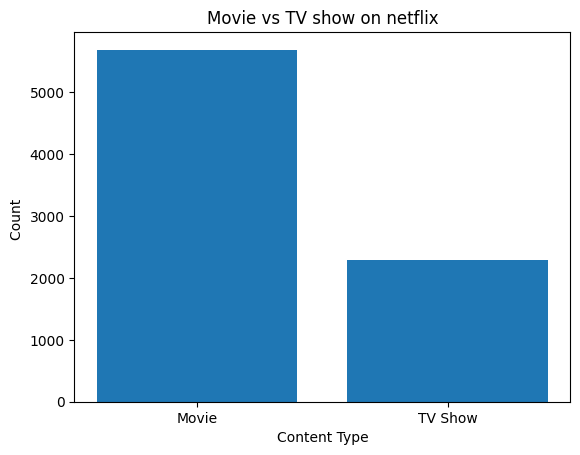

In [153]:
plt.bar(df['type'].value_counts().index,df['type'].value_counts().values)
plt.xlabel("Content Type")
plt.ylabel("Count ")
plt.title("Movie vs TV show on netflix")
plt.show()

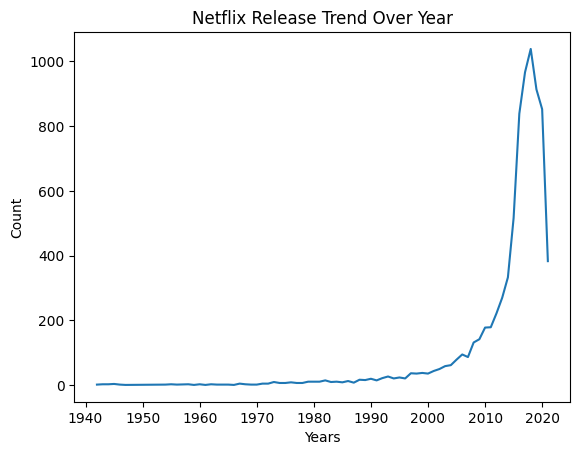

In [154]:
year_counts=df["release_year"].value_counts().sort_index()
year_counts
plt.plot(year_counts.index,year_counts.values)
plt.xlabel("Years")
plt.ylabel("Count")
plt.title("Netflix Release Trend Over Year")
plt.show()

In [155]:
df.head(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year,duration_num
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,90.0


In [156]:
df["listed_in"] = df["listed_in"].fillna("")
df["listed_in"] = df["listed_in"].str.split(",")
df["listed_in"] = df["listed_in"].apply(lambda x: [i.strip() for i in x])

df_exploded = df.explode("listed_in")

genre_counts = df_exploded["listed_in"].value_counts()
u=genre_counts.head(10)

print(f"top genres: {u}")

top genres: listed_in
International Movies      2543
Dramas                    2317
Comedies                  1580
International TV Shows    1128
Action & Adventure         817
Documentaries              794
Independent Movies         745
TV Dramas                  663
Romantic Movies            588
Thrillers                  549
Name: count, dtype: int64


In [157]:
df.head(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year,duration_num
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,[Documentaries],"As her father nears the end of his life, filmm...",2021.0,90.0


In [158]:
df.columns


Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'year', 'duration_num'],
      dtype='object')

In [159]:
x=df.country.value_counts()
x.values

array([2818,  972,  419,  245,  199,  181,  145,  124,  110,  106,  105,
         95,   87,   81,   79,   77,   75,   75,   73,   67,   66,   61,
         56,   53,   47,   45,   45,   35,   30,   27,   24,   23,   22,
         19,   18,   17,   16,   16,   16,   15,   15,   14,   14,   14,
         14,   13,   13,   13,   13,   13,   13,   12,   12,   11,   11,
         10,   10,   10,    9,    9,    8,    8,    8,    8,    7,    7,
          6,    6,    6,    6,    5,    5,    5,    5,    5,    5,    5,
          5,    5,    4,    4,    4,    4,    4,    4,    4,    4,    4,
          4,    4,    4,    4,    4,    4,    4,    4,    3,    3,    3,
          3,    3,    3,    3,    3,    3,    3,    3,    3,    3,    3,
          3,    3,    3,    3,    3,    3,    3,    3,    3,    3,    3,
          2,    2,    2,    2,    2,    2,    2,    2,    2,    2,    2,
          2,    2,    2,    2,    2,    2,    2,    2,    2,    2,    2,
          2,    2,    2,    2,    2,    2,    2,   

In [160]:
df["country"]=df["country"].mask(df['country'].value_counts()>len(df)*(2.5/100),"others")
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year,duration_num
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,others,2021-09-25,2020,PG-13,90 min,[Documentaries],"As her father nears the end of his life, filmm...",2021.0,90.0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",others,2021-09-24,2021,TV-MA,2 Seasons,"[International TV Shows, TV Dramas, TV Mysteries]","After crossing paths at a party, a Cape Town t...",2021.0,2.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",others,2021-09-24,2021,TV-MA,2 Seasons,"[International TV Shows, Romantic TV Shows, TV...",In a city of coaching centers known to train I...,2021.0,2.0
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...",others,2021-09-24,1993,TV-MA,125 min,"[Dramas, Independent Movies, International Mov...","On a photo shoot in Ghana, an American model s...",2021.0,125.0
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",others,2021-09-24,2021,TV-14,9 Seasons,"[British TV Shows, Reality TV]",A talented batch of amateur bakers face off in...,2021.0,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8801,s8802,Movie,Zinzana,Majid Al Ansari,"Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ...",others,2016-03-09,2015,TV-MA,96 min,"[Dramas, International Movies, Thrillers]",Recovering alcoholic Talal wakes up inside a s...,2016.0,96.0
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",others,2019-11-20,2007,R,158 min,"[Cult Movies, Dramas, Thrillers]","A political cartoonist, a crime reporter and a...",2019.0,158.0
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",others,2019-11-01,2009,R,88 min,"[Comedies, Horror Movies]",Looking to survive in a world taken over by zo...,2019.0,88.0
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",others,2020-01-11,2006,PG,88 min,"[Children & Family Movies, Comedies]","Dragged from civilian life, a former superhero...",2020.0,88.0


country
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
                  ... 
Sudan                1
Panama               1
Uganda               1
East Germany         1
Montenegro           1
Name: count, Length: 123, dtype: int64


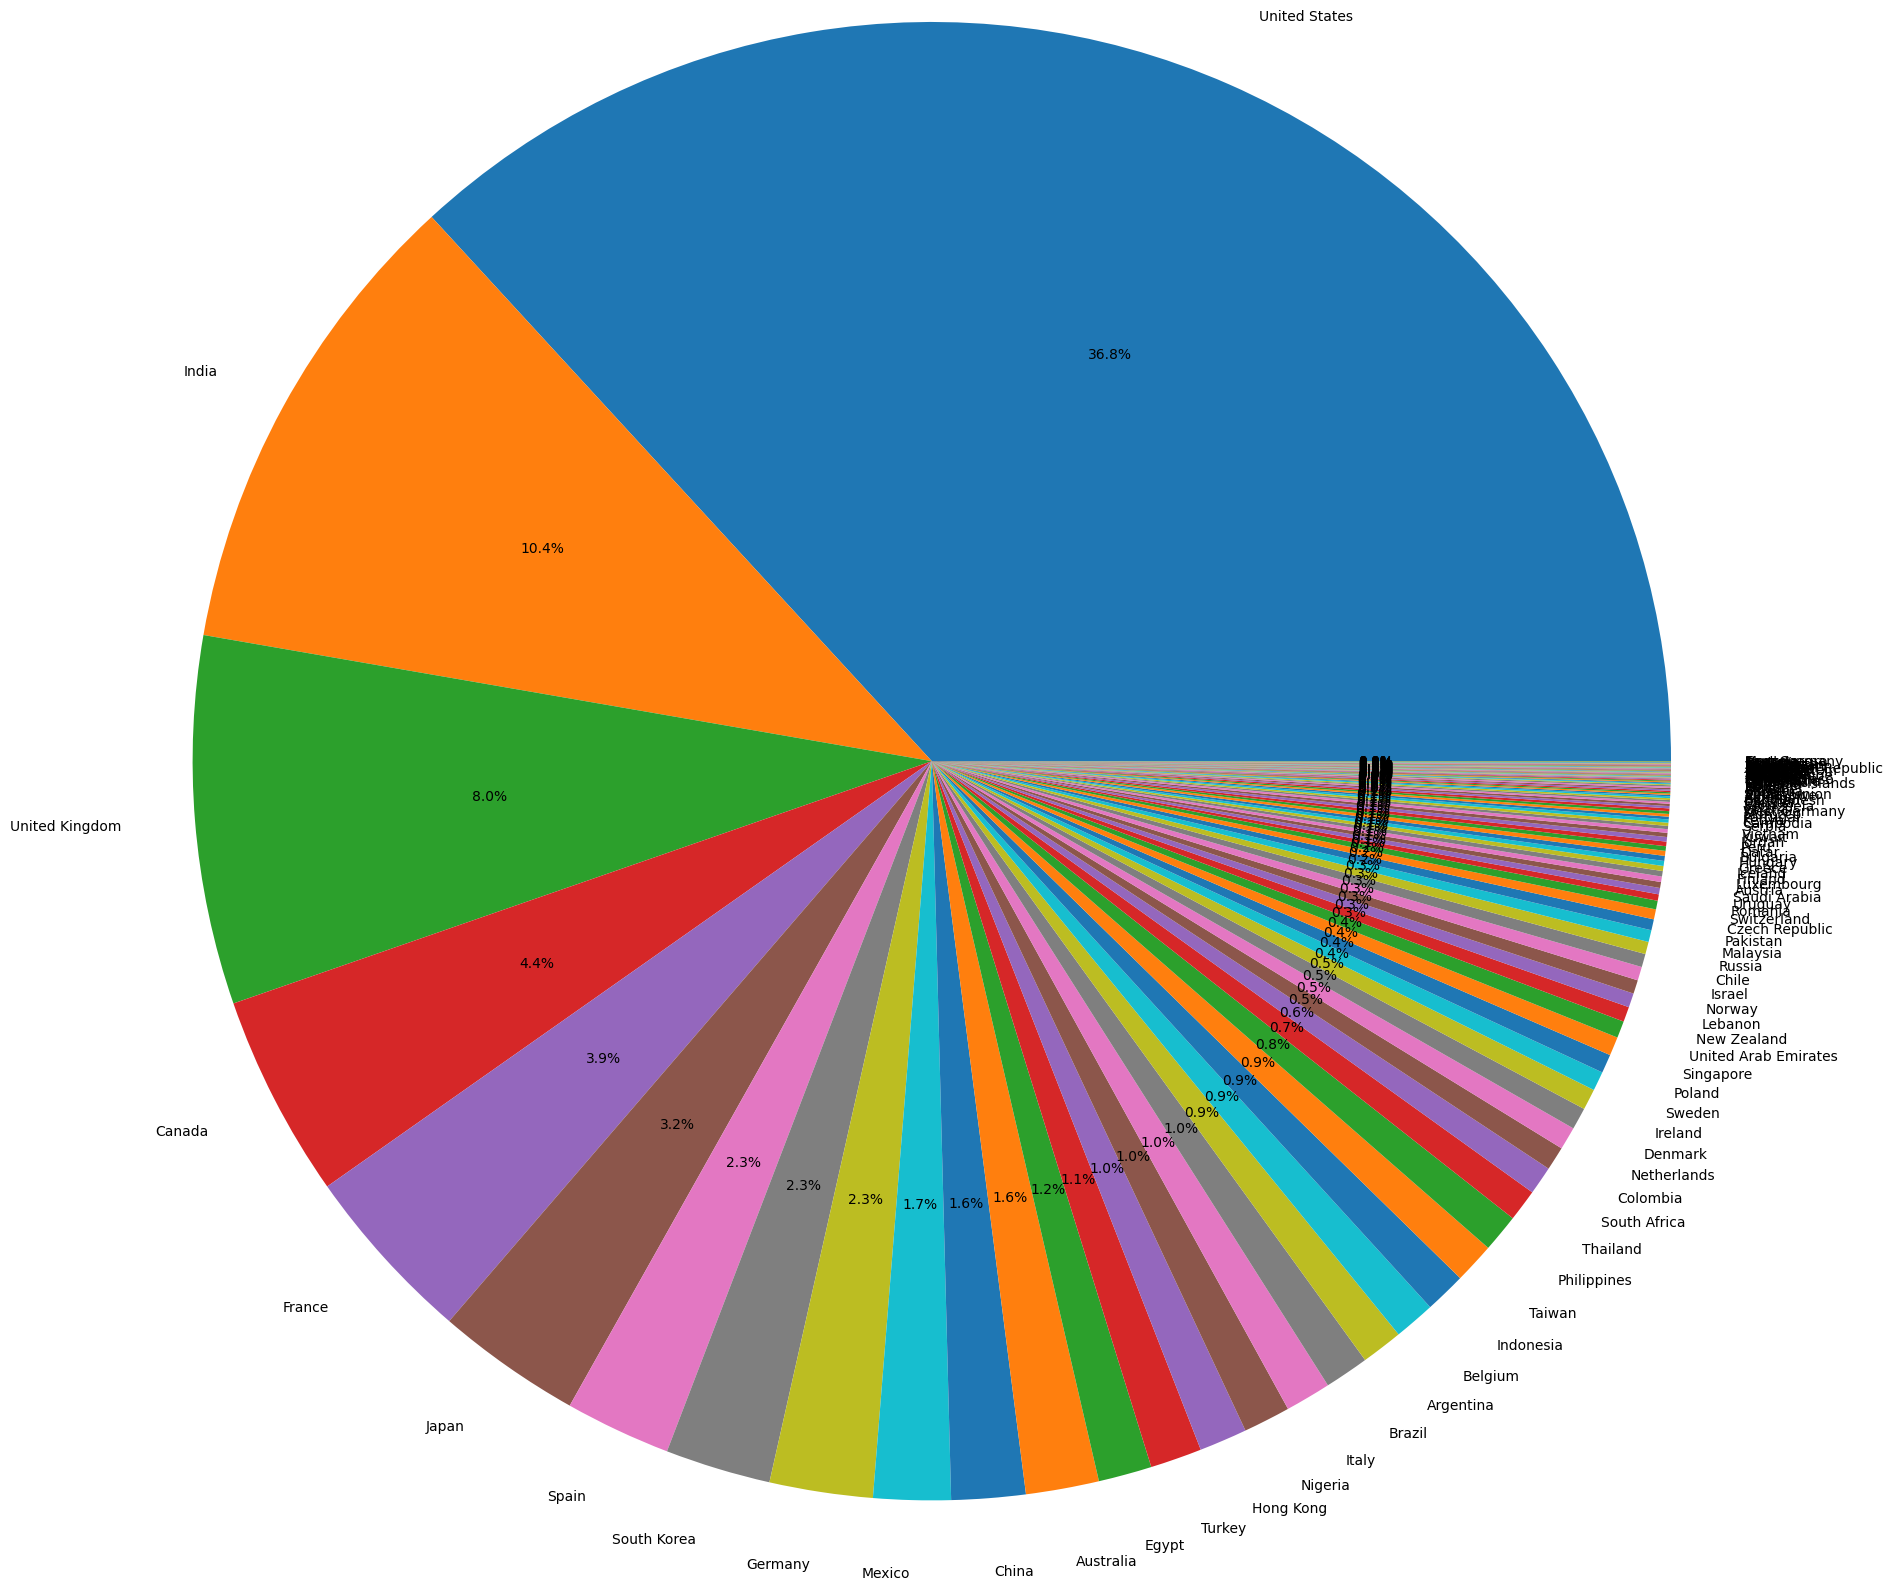

In [161]:
df=pd.read_csv(r"C:\Users\vishw\Music\Downloads\netflix_titles.csv.zip")
df.isnull().sum()
df.dropna(subset=["country"],inplace=True)
df['country']=df['country'].str.split(",").apply(lambda x: [i.strip() for i in x])
df=df.explode("country")
d=df["country"].value_counts()


# d=d.mask(d>len(df)*(1/100),"others")
np.where(d>len(df)*(1/100),d.index,"others")
print(d)


x=d.values
y=d.index
plt.pie(x,labels=y,autopct="%1.1f%%",radius=5)
plt.show()

In [162]:
df.head(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."


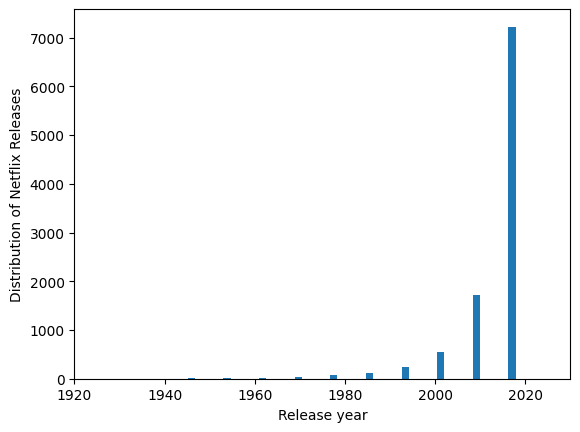

In [163]:
plt.hist(df["release_year"],bins=10,rwidth=0.2)
plt.gca().set_xlim(1920,2030)
plt.xlabel("Release year")
plt.ylabel("Distribution of Netflix Releases")
plt.show()